In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import torchinfo
import os

# 1. Environment Setup & Hardware Verification
print(f"PyTorch Version: {torch.__version__}")

# Verify PyTorch recognizes the AMD GPU natively via ROCm
print(f"HIP/ROCm version built with PyTorch: {torch.version.hip}")
print(f"Is GPU Acceleration available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

# Assign device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch Version: 2.11.0+rocm7.2
HIP/ROCm version built with PyTorch: 7.2.26015
Is GPU Acceleration available? True
Device Name: AMD Radeon RX 6800S


## 2. Data Loading & Preprocessing

The standard YOLO classifier takes images with shape `[3, 224, 224]`. Here we construct our `DataLoaders`, scaling all characters accordingly while normalizing the color channels for optimal feature mapping.


In [2]:
# Paths to your dataset according to the project structure
train_dir = "./data/final/train"
val_dir = "./data/final/val"

# Define standard transformation pipeline for 224x224 classification
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # Standard ImageNet scaling stats generally work best for pretrained YOLO backbones
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Create Dataset objects representing the 20 Javanese characters
train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)

# DataLoaders for vectorizing inputs in batches
batch_size = 32
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=True
)

classes = train_dataset.classes
print(f"Loaded {len(classes)} classes: {classes}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

# Verify the tensor dimensions:
# Should output [Batch_Size, Color_Channels, Height, Width] -> [32, 3, 224, 224]
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape check: {sample_batch.shape}")

Loaded 20 classes: ['ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya']
Train samples: 2154 | Val samples: 480
Batch shape check: torch.Size([32, 3, 224, 224])


## 3. Model Initialization & Architecture Inspection

We load the YOLO26 nano classification architecture (`yolo26n-cls.pt`). Since we need strict white-box feature extraction control, we'll extract the underlying PyTorch `nn.Module` from the Ultralytics wrapper.

This enables two things:

1. Complete transparency of tensor matrix transformations (from $3 \times 224 \times 224$ to a flat feature pool, culminating in a 20-dimension output vector).
2. Proper hook placement on the penultimate Convolutional spatial layer for **Grad-CAM**.


In [3]:
# Load the YOLO model natively
model_wrapper = YOLO("yolo26n-cls.pt")

# Extract actual pytorch nn.Module from wrapper to expose hooks natively to Captum/Grad-CAM
base_model = model_wrapper.model

# The pre-trained YOLO model was trained on ImageNet and outputs 1000 classes.
# We must replace the final linear classification layer to output our 20 Aksara Jawa classes instead.
in_features = base_model.model[-1].linear.in_features
base_model.model[-1].linear = nn.Linear(in_features, len(classes))

base_model = base_model.to(device)

# Ensure parameters require gradients for fine-tuning
for param in base_model.parameters():
    param.requires_grad = True

# Ensure the final output layer correctly targets [Batch, 20] corresponding to our 20 Aksara Jawa classes
# Note: typically YOLO classifiers end in a sequential block. We will just let torchinfo map it:
print("\n--- Model Architecture & Forward Pass Shape Verification ---")
torchinfo.summary(
    base_model,
    input_size=(batch_size, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params"],
    depth=4,
)

# We will need the final convolutional block for Grad-CAM.
# Generally in Ultralytics this is the layer immediately before the final GAP (Global Average Pooling) and Linear layer.
# Printing model layers to find target `target_layer = base_model...` is handled later in the XAI section.


--- Model Architecture & Forward Pass Shape Verification ---


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
ClassificationModel                                          [32, 3, 224, 224]         [32, 20]                  --
├─Sequential: 1-1                                            --                        --                        --
│    └─Conv: 2-1                                             [32, 3, 224, 224]         [32, 16, 112, 112]        --
│    │    └─Conv2d: 3-1                                      [32, 3, 224, 224]         [32, 16, 112, 112]        432
│    │    └─BatchNorm2d: 3-2                                 [32, 16, 112, 112]        [32, 16, 112, 112]        32
│    │    └─SiLU: 3-3                                        [32, 16, 112, 112]        [32, 16, 112, 112]        --
│    └─Conv: 2-2                                             [32, 16, 112, 112]        [32, 32, 56, 56]          --
│    │    └─Conv2d: 3-4                                      [32, 

## 4. Fine-Tuning Training Loop

A standard cross-entropy training pipeline optimizing the 20-dimensional output character vector mappings via AdamW.


In [4]:
num_epochs = 30
best_acc = 0.0

# Early stopping parameters
patience = 5
patience_counter = 0

# Calculate class weights to handle any class imbalance
class_counts = np.bincount(train_dataset.targets)
total_samples = len(train_dataset)
num_classes = len(classes)
class_weights = total_samples / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(base_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)  # Tambahan Scheduler

# Tambahan Scaler untuk AMP (ROCm mendukung ini via abstraksi cuda)
scaler = torch.amp.GradScaler("cuda")

print("Starting Optimized Fine-tuning loop on AMD ROCm backend...")
for epoch in range(num_epochs):
    base_model.train()
    running_loss, correct, total = 0.0, 0, 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # AMP: Cast forward pass ke precision yang lebih rendah (FP16/BF16)
        with torch.autocast(device_type="cuda"):
            outputs = base_model(inputs)
            if isinstance(outputs, tuple) or isinstance(outputs, list):
                outputs = outputs[0]
            loss = criterion(outputs, labels)

        # AMP: Backward pass yang diskalakan
        scaler.scale(loss).backward()

        # Gradient Clipping (Opsional tapi direkomendasikan)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), max_norm=1.0)

        # AMP: Optimizer step dan update scaler
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        train_pbar.set_postfix(
            {"loss": f"{loss.item():.4f}", "acc": f"{100.0 * correct / total:.2f}%"}
        )

    scheduler.step()  # Update LR setiap akhir epoch

    train_acc = 100.0 * correct / total
    avg_train_loss = running_loss / total  # Rata-rata training loss

    # Validation step
    base_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]")
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.autocast(device_type="cuda"):
                outputs = base_model(inputs)
                if isinstance(outputs, tuple) or isinstance(outputs, list):
                    outputs = outputs[0]
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            val_pbar.set_postfix(
                {
                    "loss": f"{loss.item():.4f}",
                    "acc": f"{100.0 * val_correct / val_total:.2f}%",
                }
            )

    val_acc = 100.0 * val_correct / val_total
    avg_val_loss = val_loss / val_total  # Rata-rata validation loss

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} -> "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

    # Early Stopping & Checkpoint Logic
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0  # reset patience
        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": base_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc": best_acc,
        }

        # Create model directory if not exists
        import os

        os.makedirs("model", exist_ok=True)
        torch.save(checkpoint, "model/best_model.pt")
        print("Model checkpoint saved! (Accuracy Improved)")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break

print(f"Training Complete. Peak Val Accuracy: {best_acc:.2f}%")

Starting Optimized Fine-tuning loop on AMD ROCm backend...


Epoch 01/30 [Train]:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 01/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/30 -> Train Loss: 0.7498 | Train Acc: 78.46% || Val Loss: 2.1398 | Val Acc: 96.46% | LR: 0.000997
Model checkpoint saved! (Accuracy Improved)


Epoch 02/30 [Train]:   0%|          | 0/68 [00:00<?, ?it/s]

...

Epoch 08/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 08/30 -> Train Loss: 0.0142 | Train Acc: 99.58% || Val Loss: 2.1332 | Val Acc: 95.00% | LR: 0.000835
No improvement. Patience: 4/5


Epoch 09/30 [Train]:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 09/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 09/30 -> Train Loss: 0.0098 | Train Acc: 99.77% || Val Loss: 2.1060 | Val Acc: 97.71% | LR: 0.000794
No improvement. Patience: 5/5
Early stopping triggered at epoch 9!
Training Complete. Peak Val Accuracy: 99.17%


## 5. Explainable AI (XAI) - Gradient-weighted Class Activation Mapping (Grad-CAM)

To extract meaningful spatial interpretation out of the YOLO model's final vector prediction, we utilize **Grad-CAM**.

### Mathematical Foundation of Grad-CAM

A CNN transforms an input image tensor $X \in \mathbb{R}^{3 \times 224 \times 224}$ into a class score vector $Y^c$ mapped over a set of classes $C$. Grad-CAM extracts a localization map $L_{Grad-CAM}^c \in \mathbb{R}^{W_k \times H_k}$ for a specific class $c$, generated from the final convolutional block.

Let $A^k$ be the spatial activation map of the $k$-th feature channel of the final convolutional layer. Grad-CAM computes the gradient of the class score $y^c$ with respect to the feature map activations:

$$ \frac{\partial y^c}{\partial A^k} $$

These gradients are global-average-pooled spatially (over $i$ and $j$, representing height and width) to obtain the neural importance weight $\alpha_k^c$ of the $k$-th feature channel to the target vector path:

$$ \alpha*k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A*{ij}^k} $$

We perform a weighted linear combination of the forward-pass activation maps $\alpha_k^c A^k$, followed by a ReLU scalar projection to ensure we only look at features having a **positive** influence on the Javanese character classified:

$$ L\_{Grad-CAM}^c = ReLU \left( \sum_k \alpha_k^c A^k \right) $$

In this block, we map the final convolutional layer of YOLO26 to calculate $\alpha_k^c$.


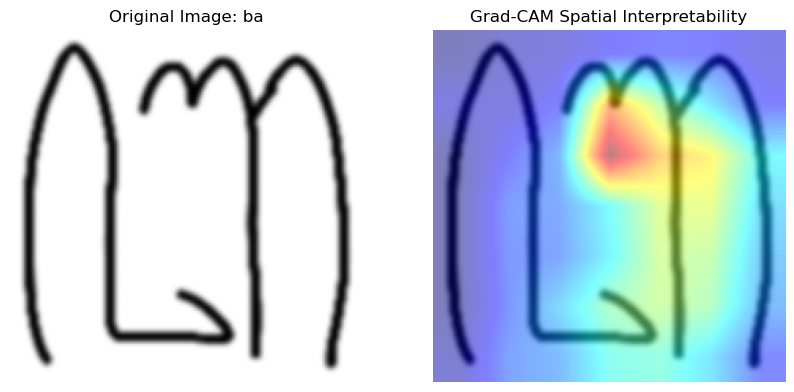

In [5]:
# !pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

# For YOLO architectures, the target is usually the last sub-module in the backbone
# You may need to replace `base_model.model[-2]` dynamically depending on `torchinfo` outputs
# It must be a 2D Spatial module (e.g., Conv2d, C2f, or standard bottleneck layer)
target_layers = [base_model.model[-2]]

# Re-load our best fine-tuned weights
# We saved a checkpoint dict earlier, so we need to extract 'model_state_dict' specifically
checkpoint = torch.load("model/best_model.pt", map_location=device)
base_model.load_state_dict(checkpoint["model_state_dict"])
base_model.eval()

# Retrieve a sample test image for visualization
sample_img_path = os.path.join(
    val_dir, classes[0], os.listdir(os.path.join(val_dir, classes[0]))[0]
)
img_pil = Image.open(sample_img_path).convert("RGB")
input_tensor = transform(img_pil).unsqueeze(0).to(device)

# Initialize Grad-CAM
# `use_cuda` is true if device is cuda, which supports AMD ROCm interchangeably.
cam = GradCAM(model=base_model, target_layers=target_layers)

# Target the specific character class index (e.g. index 0 -> 'ba')
targets = [ClassifierOutputTarget(0)]

# Calculate localized mapping
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

# Visualize GradCAM overlay
np_img = np.array(img_pil.resize((224, 224))) / 255.0
heatmap_overlay = show_cam_on_image(np_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np_img)
plt.title(f"Original Image: {classes[0]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(heatmap_overlay)
plt.title("Grad-CAM Spatial Interpretability")
plt.axis("off")
plt.show()

## 6. Explainable AI (XAI) - Captum Integrated Gradients

While Grad-CAM explains the network at a purely structural (macro) activation level, **Integrated Gradients** provides _pixel-perfect attribution_. This technique proves exactly which pixels positively correlate to the mathematical vector representation of a specific Javanese Character.

### Riemann Sum Approximation of Pixel Mapping

Integrated Gradients defines attribution as the integral of gradients sampled along a linear path from a baseline vector $x'$ (often zero matrix/black image) to the input tensor $x$.

For a function $F : \mathbb{R}^n \rightarrow \mathbb{R}$ (our YOLO classifier returning a scaler path probability), the Integrated Gradient attribution for the $i$-th pixel feature is strictly modeled as:

$$ IntegratedGrads*i(x) ::= (x_i - x'\_i) \times \int*{\alpha=0}^{1} \frac{\partial F(x' + \alpha \times (x - x'))}{\partial x_i} d\alpha $$

Where:

- $x$ is the input image configuration of the character.
- $x'$ is the baseline (baseline tensors act as standard background noise).
- $\alpha \in [0, 1]$ represents the scaling coefficient interpolating along a straight line path to the image.

In practical GPU pipelines, PyTorch computes the continuous integral using discrete Riemann sum mathematical approximation over $m$ steps ($m = 50$ mostly ensures convergence precision without exhausting GPU resources):

$$ IntegratedGrads*i^{approx}(x) ::= (x_i - x'\_i) \times \sum*{k=1}^{m} \frac{\partial F(x' + \frac{k}{m} \times (x - x'))}{\partial x_i} \times \frac{1}{m} $$

By plotting this sum, green pixels (positive gradients) push the vector output closer to predicting our 20-dimension class, while red (negative gradients) mathematically push it away.


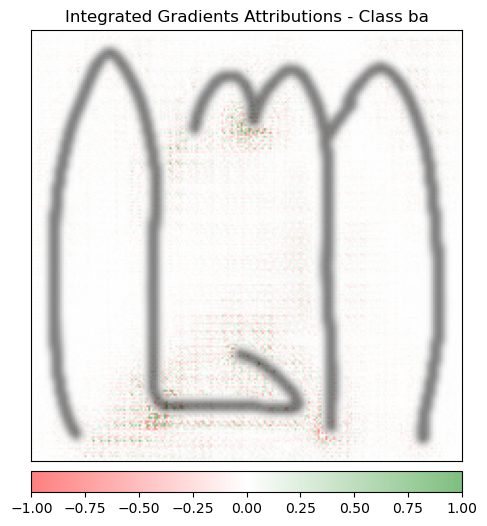

Approximation convergence delta metric (should be near 0): 0.0029


In [6]:
# !pip install captum

from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

# Ensure requires_grad is available for input mapping
input_tensor.requires_grad = True


# We need a wrapper function because YOLO architectures often return a tuple of
# (predictions, features) during the forward pass, and Captum expects a single Tensor.
def custom_forward(inputs):
    outputs = base_model(inputs)
    if isinstance(outputs, tuple) or isinstance(outputs, list):
        return outputs[0]
    return outputs


# Initialize Integrated Gradients passing the custom forward function
# so Captum can perform automated backwards integration hooks.
ig = IntegratedGradients(custom_forward)

# Compute attributions using standard 50-step Riemann sum mapping
# target=0 refers to the 0th index out of 20 classes ('ba')
attributions_ig, delta = ig.attribute(
    input_tensor, target=0, return_convergence_delta=True
)

# Post-process tensors for visualization rendering
# Input formatting: Permute dims from [C, H, W] -> [H, W, C]
orig_img_np = np.transpose(input_tensor.squeeze().cpu().detach().numpy(), (1, 2, 0))

# Attribution formatting: Aggregate across channels and normalize
attr_ig_np = np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1, 2, 0))

# Captum's visualize_image_attr plots pixel-perfect correlations
_ = viz.visualize_image_attr(
    attr_ig_np,
    orig_img_np,
    method="blended_heat_map",
    sign="all",  # Red = Negative correlation, Green = Positive correlation
    show_colorbar=True,
    title=f"Integrated Gradients Attributions - Class {classes[0]}",
)

print(f"Approximation convergence delta metric (should be near 0): {delta.item():.4f}")